In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz
from scipy.signal import lfilter

np.random.seed(0)
n = 500
# Original clean signal (e.g., reflectivity or wavelet)
t = np.linspace(0, 1, n)
signal = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 15 * t)

# Additive noise
noise = 0.5 * np.random.randn(n)
noisy_signal = signal + noise


In [2]:
def wiener_filter(x, d, M):
    """Estimate Wiener filter of length M given input x and desired d."""
    r_xx = np.correlate(x, x, mode='full') / len(x)
    r_xd = np.correlate(d, x, mode='full') / len(x)
    
    mid = len(x) - 1
    R = toeplitz(r_xx[mid:mid+M])
    p = r_xd[mid:mid+M]
    
    h = np.linalg.solve(R, p)
    return h

# Design Wiener filter
M = 20
h_wiener = wiener_filter(noisy_signal, signal, M)
wiener_output = lfilter(h_wiener, 1, noisy_signal)


In [3]:
def yule_walker(x, order):
    """Yule-Walker AR coefficient estimation."""
    r = np.correlate(x, x, mode='full') / len(x)
    mid = len(x) - 1
    R = toeplitz(r[mid:mid+order])
    rhs = -r[mid+1:mid+order+1]
    a = np.linalg.solve(R, rhs)
    return np.concatenate(([1.0], a))  # include leading 1

# Estimate AR coefficients
p = 20
ar_coeffs = yule_walker(noisy_signal, p)
ar_output = lfilter(ar_coeffs, 1, noisy_signal)  # Apply whitening filter


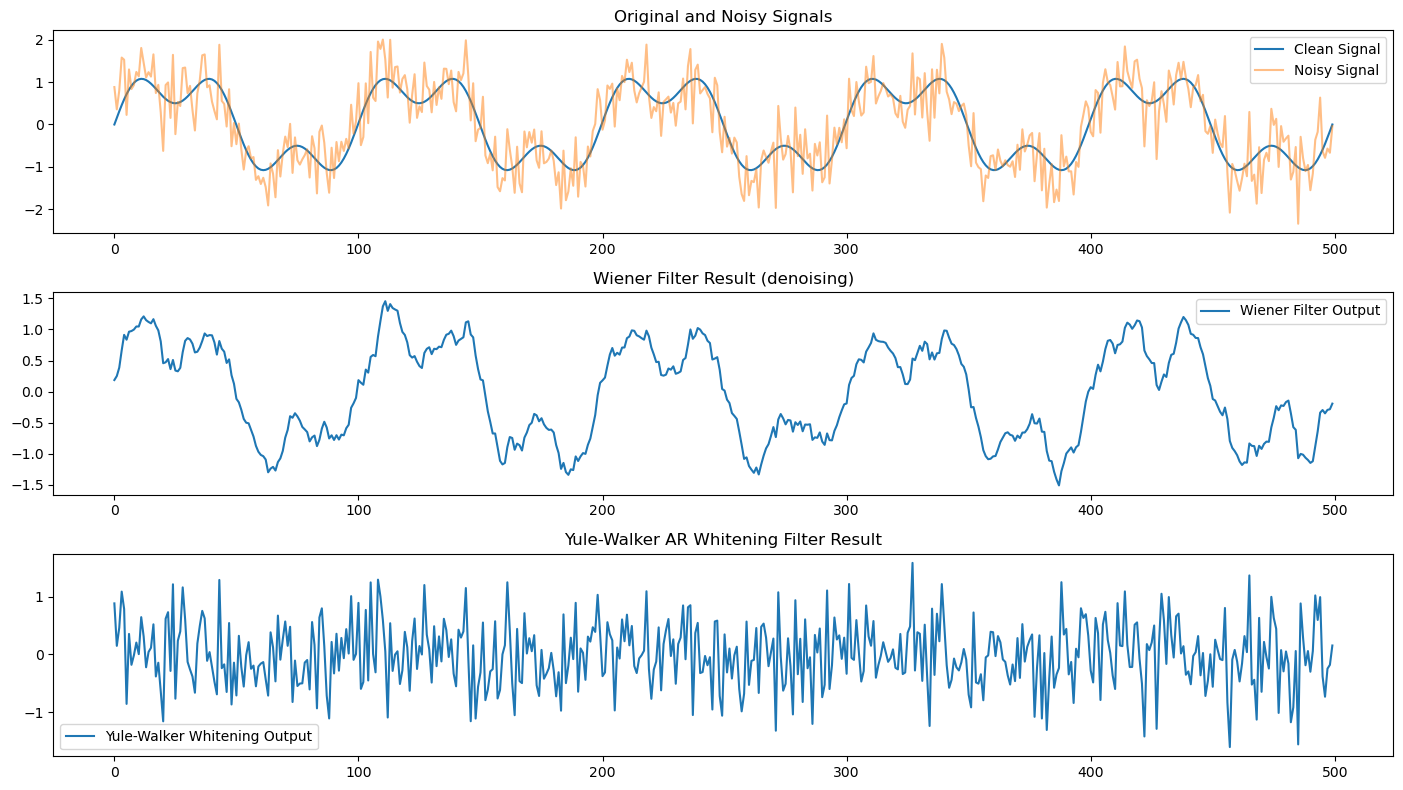

In [4]:
plt.figure(figsize=(14, 8))

plt.subplot(3, 1, 1)
plt.plot(signal, label="Clean Signal")
plt.plot(noisy_signal, alpha=0.5, label="Noisy Signal")
plt.legend()
plt.title("Original and Noisy Signals")

plt.subplot(3, 1, 2)
plt.plot(wiener_output, label="Wiener Filter Output")
plt.legend()
plt.title("Wiener Filter Result (denoising)")

plt.subplot(3, 1, 3)
plt.plot(ar_output, label="Yule-Walker Whitening Output")
plt.legend()
plt.title("Yule-Walker AR Whitening Filter Result")

plt.tight_layout()
plt.show()
